# PyTorch Workflow Fundamentals

In [86]:
import torch
import matplotlib.pyplot as plt
from torch import nn
from pathlib import Path

## 1. Data (preparing and loading)

In [87]:
# membuat parameter
weight = 0.7
bias = 0.3

# membuat  data
start = 0
end  = 1
step = 0.02

X = torch.arange(start=start,end=end,step=step).unsqueeze(dim=1)
y = weight * X + bias

X [: 10 ],  y [: 10 ]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [88]:
# Buat pembagian data latih/uji 

train_split = int(0.8 * len(X))
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [89]:
# membuat Visualisasi
def plot_predictions(train_data=X_train,train_labels=y_train,test_data=X_test,test_labels=y_test,predictions = None):
    """Plots training data, test data and compares predictions."""
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_labels,c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    plt.legend(prop={'size':15})

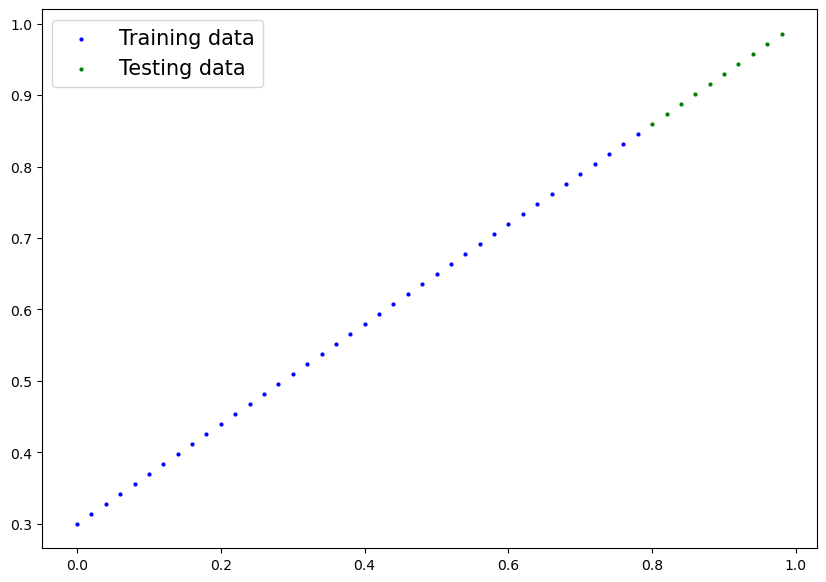

In [90]:
plot_predictions()

## 2. Build model

In [91]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)

    def forward(self,X:torch.Tensor)-> torch.Tensor:
        return self.weights * X + self.bias

### 2.1 Checking the contents of a PyTorch model

In [93]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()

list(model_0.parameters()),model_0.state_dict()

([Parameter containing:
  tensor([0.3367], requires_grad=True),
  Parameter containing:
  tensor([0.1288], requires_grad=True)],
 OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))]))

### 2.2 Making predictions using torch.inference_mode()

In [95]:
with torch.inference_mode():
    y_preds = model_0(X_test)

print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


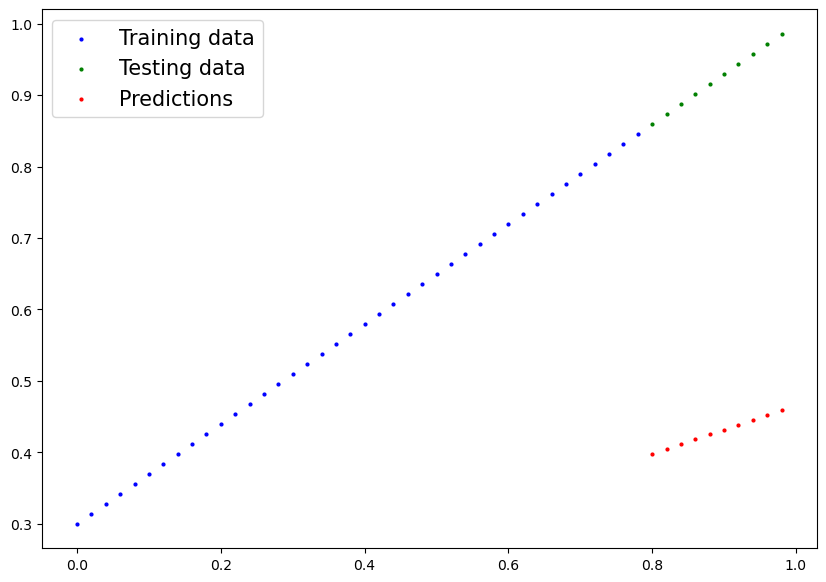

In [96]:
plot_predictions(predictions=y_preds)

## 3. Train model

In [98]:
# Create the loss function
loss_func = nn.L1Loss()

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.02)

### 3.1 Creating an optimization loop in PyTorch

In [100]:
torch.manual_seed(42)

epochs = 100
trains_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    model_0.train()
    y_pred = model_0(X_train)
    loss = loss_func(y_pred,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_func(test_pred,y_test.type(torch.float))
        if epoch % 10 == 0 :
            epoch_count.append(epoch)
            trains_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.4675941467285156 
Epoch: 10 | MAE Train Loss: 0.08831816911697388 | MAE Test Loss: 0.20536987483501434 
Epoch: 20 | MAE Train Loss: 0.04547790437936783 | MAE Test Loss: 0.11100725829601288 
Epoch: 30 | MAE Train Loss: 0.03829658776521683 | MAE Test Loss: 0.08761118352413177 
Epoch: 40 | MAE Train Loss: 0.031427789479494095 | MAE Test Loss: 0.072440005838871 
Epoch: 50 | MAE Train Loss: 0.02456694096326828 | MAE Test Loss: 0.055895041674375534 
Epoch: 60 | MAE Train Loss: 0.017689326778054237 | MAE Test Loss: 0.03935007005929947 
Epoch: 70 | MAE Train Loss: 0.010823884978890419 | MAE Test Loss: 0.024178892374038696 
Epoch: 80 | MAE Train Loss: 0.003965773619711399 | MAE Test Loss: 0.006277936510741711 
Epoch: 90 | MAE Train Loss: 0.01409052312374115 | MAE Test Loss: 0.005287045147269964 


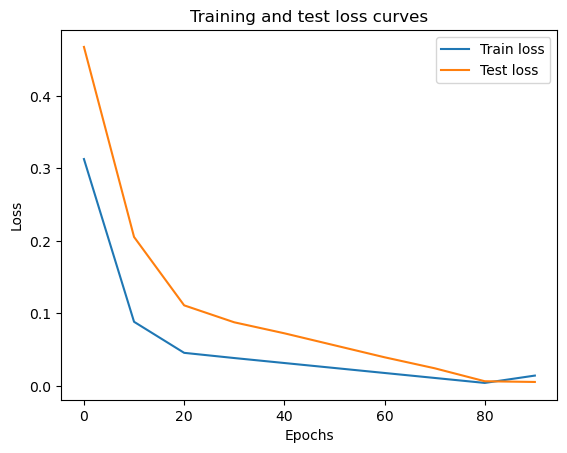

In [101]:
plt.plot(epoch_count, trains_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [102]:
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.6849]), 'bias': tensor([0.2918])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


## 4. Making predictions with a trained PyTorch model 

In [104]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

tensor([[0.8397],
        [0.8534],
        [0.8671],
        [0.8808],
        [0.8945],
        [0.9082],
        [0.9219],
        [0.9356],
        [0.9493],
        [0.9630]])

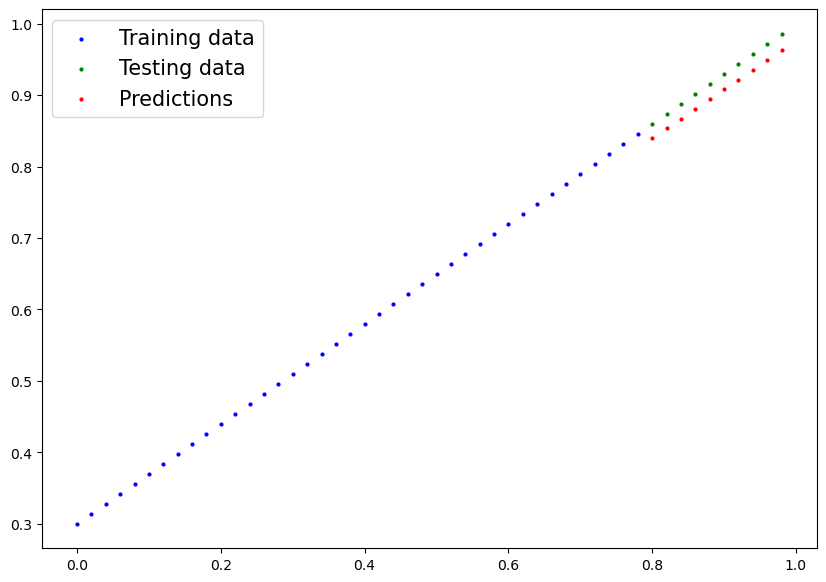

In [105]:
plot_predictions(predictions=y_preds)

## 5. Saving and loading a PyTorch model

In [107]:
#buat direktori
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True,exist_ok=True)

# 2. Buat jalur penyimpanan model 
MODEL_NAME  =  "01_pytorch_workflow_model_0.pth" 
MODEL_SAVE_PATH  =  MODEL_PATH  /  MODEL_NAME

# 3. Simpan state dict model 
print (f"Menyimpan model ke: { MODEL_SAVE_PATH }") 
torch . save ( obj = model_0 . state_dict (),  # hanya menyimpan state_dict() hanya menyimpan parameter yang dipelajari model 
           f = MODEL_SAVE_PATH )

Menyimpan model ke: models\01_pytorch_workflow_model_0.pth


### 5.1 Loading a saved PyTorch model's

In [109]:
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])